In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

# KoELECTRA 토크나이저 예시 (논문에서 사용된 모델 중 하나)
tokenizer = AutoTokenizer.from_pretrained("monologg/koelectra-base-v3-discriminator")

# 데이터 로드 (사용자 파일명 기준)
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

c:\Users\user\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--monologg--koelectra-base-v3-discriminator. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[Wellness 데이터셋 통계]
- 총 데이터 개수: 19,666
- 평균 토큰 길이: 12.67
- 최대 토큰 길이: 52
- 95% 데이터가 포함되는 길이: 21.0
------------------------------
[Chatbot 데이터셋 통계]
- 총 데이터 개수: 5,261
- 평균 토큰 길이: 5.98
- 최대 토큰 길이: 17
- 95% 데이터가 포함되는 길이: 10.0
------------------------------
[Subject 데이터셋 통계]
- 총 데이터 개수: 1,370,984
- 평균 토큰 길이: 10.81
- 최대 토큰 길이: 100
- 95% 데이터가 포함되는 길이: 20.0
------------------------------


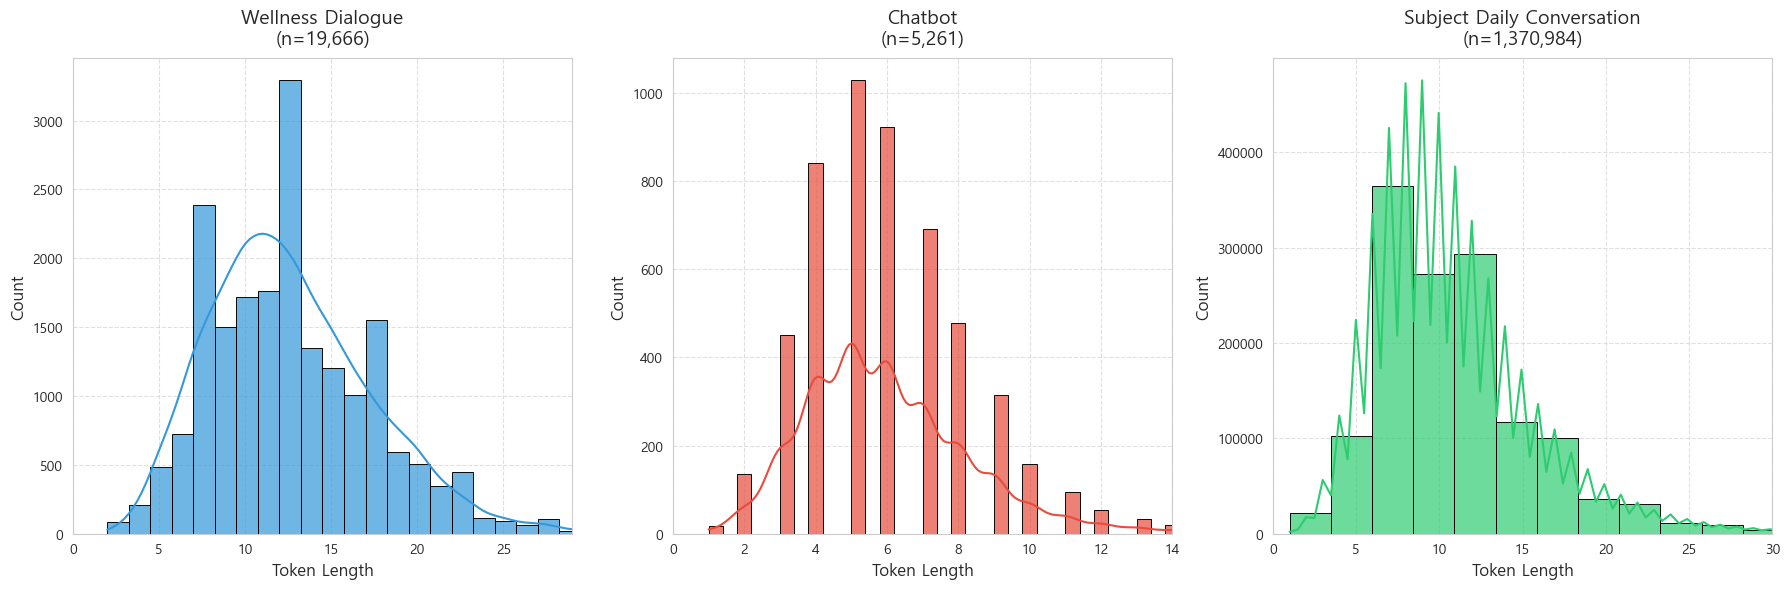

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic') 

# 2. 통계치 계산 및 출력 함수
def print_stats(name, lens):
    print(f"[{name} 데이터셋 통계]")
    print(f"- 총 데이터 개수: {len(lens):,}")
    print(f"- 평균 토큰 길이: {np.mean(lens):.2f}")
    print(f"- 최대 토큰 길이: {np.max(lens)}")
    print(f"- 95% 데이터가 포함되는 길이: {np.percentile(lens, 95)}")
    print("-" * 30)

# 3. 데이터셋별 통계 출력
print_stats("Wellness", wellness_lens)
print_stats("Chatbot", chatbot_lens)
print_stats("Subject", subject_lens)

# 4. 데이터 맞춤형 시각화 (1행 3열)
# sharey=False를 사용해 각 데이터셋의 개수에 맞춰 y축이 자동 조절되게 합니다.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

data_list = [wellness_lens, chatbot_lens, subject_lens]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Daily Conversation']
colors = ['#3498db', '#e74c3c', '#2ecc71'] # 각각 다른 색상 적용

for i, lens in enumerate(data_list):
    # 히스토그램 그리기
    sns.histplot(lens, bins=40, ax=axes[i], kde=True, color=colors[i], edgecolor='black', alpha=0.7)
    
    # 제목 및 레이블
    axes[i].set_title(f"{titles[i]}\n(n={len(lens):,})", fontsize=14, pad=10)
    axes[i].set_xlabel('Token Length', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # [핵심] x축 범위를 데이터의 실제 최대값에 맞추거나, 
    # 너무 긴 아웃라이어가 있다면 99% 지점으로 설정하여 가독성을 높입니다.
    x_limit = np.percentile(lens, 99.5) # 상위 0.5%를 제외한 지점까지 보여줌 (추천)
    axes[i].set_xlim(0, x_limit) 
    
    # 격자선 최적화
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

[Wellness 데이터셋 실제 수치]
- 전체 데이터 수: 19,666
- 평균 토큰 길이: 14.67
- 최소/최대 길이: 4 / 54
- 상위 95% 지점: 23.0
-----------------------------------
[Chatbot 데이터셋 실제 수치]
- 전체 데이터 수: 5,261
- 평균 토큰 길이: 7.98
- 최소/최대 길이: 3 / 19
- 상위 95% 지점: 12.0
-----------------------------------
[Subject 데이터셋 실제 수치]
- 전체 데이터 수: 1,370,984
- 평균 토큰 길이: 12.81
- 최소/최대 길이: 3 / 102
- 상위 95% 지점: 22.0
-----------------------------------


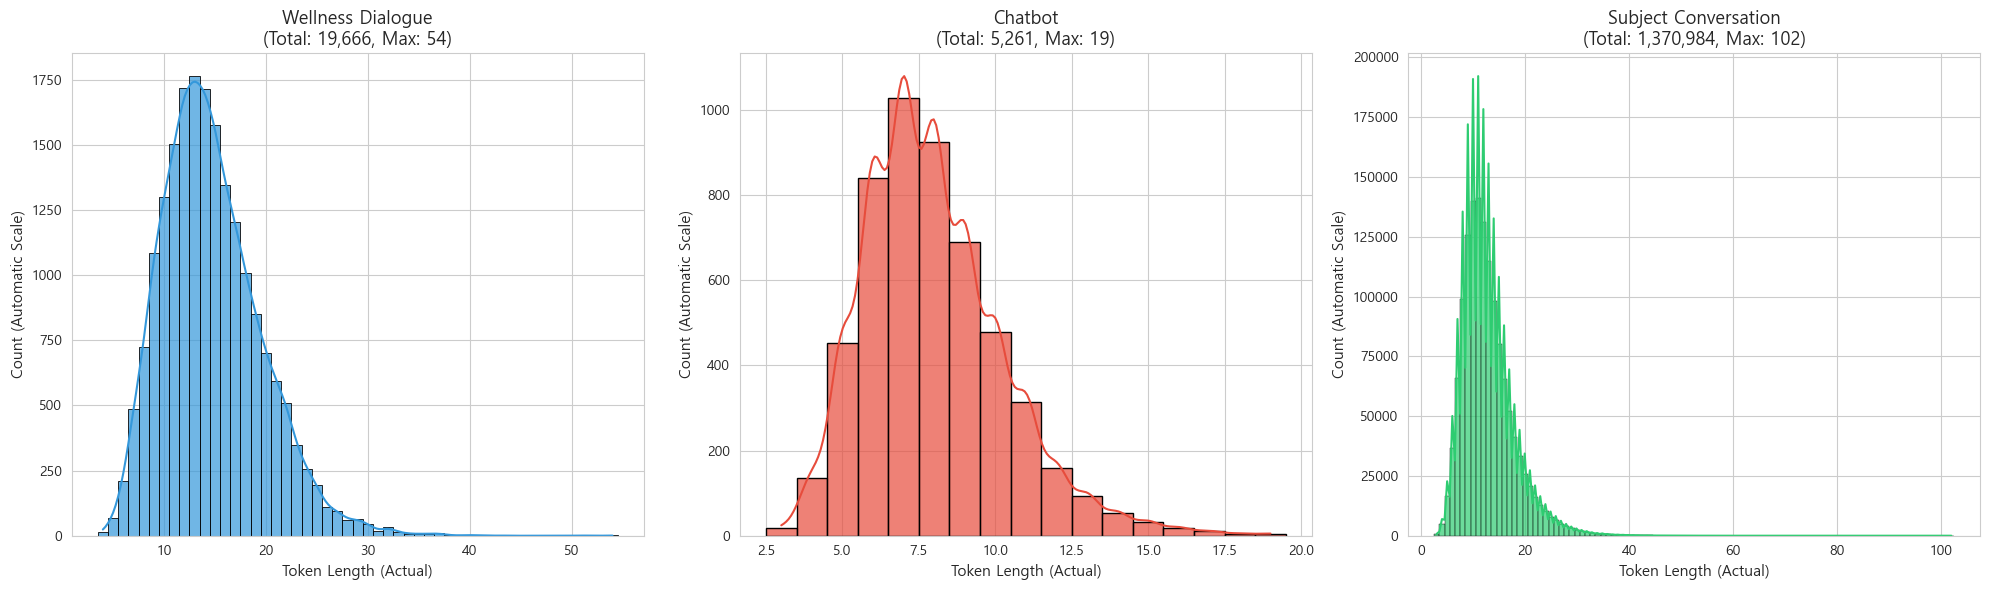

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import AutoTokenizer

# 1. 환경 설정 및 데이터 로드 (파일 경로는 본인 환경에 맞게 확인하세요)
tokenizer = AutoTokenizer.from_pretrained("monologg/koelectra-base-v3-discriminator")

# 데이터 로드 (사용자 파일명 기준)
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

# 2. 토큰 길이 계산 함수
def get_token_lengths(texts, tokenizer):
    return [len(tokenizer.encode(str(text), add_special_tokens=True)) for text in texts]

wellness_lens = get_token_lengths(df_wellness['utterance'], tokenizer)
chatbot_lens = get_token_lengths(df_chatbot['utterance'], tokenizer)
subject_lens = get_token_lengths(df_subject['utterance'], tokenizer)

# 3. 통계치 계산 및 출력 (데이터의 실제 범위를 숫자로 먼저 확인)
def print_auto_stats(name, lens):
    print(f"[{name} 데이터셋 실제 수치]")
    print(f"- 전체 데이터 수: {len(lens):,}")
    print(f"- 평균 토큰 길이: {np.mean(lens):.2f}")
    print(f"- 최소/최대 길이: {np.min(lens)} / {np.max(lens)}")
    print(f"- 상위 95% 지점: {np.percentile(lens, 95)}")
    print("-" * 35)

print_auto_stats("Wellness", wellness_lens)
print_auto_stats("Chatbot", chatbot_lens)
print_auto_stats("Subject", subject_lens)

# 4. 시각화 (축 범위 제한 없음, 막대 붙임)
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic') # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False) # y축 자동 조절

data_list = [wellness_lens, chatbot_lens, subject_lens]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Conversation']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, lens in enumerate(data_list):
    # discrete=True: 정수 값에 맞춰 막대를 배치
    # shrink=1: 막대 사이의 간격을 0으로 만들어 모두 붙임
    sns.histplot(lens, ax=axes[i], kde=True, discrete=True, 
                 color=colors[i], edgecolor='black', alpha=0.7, shrink=1)
    
    # 제목에 데이터 개수와 최대 길이를 자동으로 표시
    axes[i].set_title(f"{titles[i]}\n(Total: {len(lens):,}, Max: {max(lens)})", fontsize=13)
    axes[i].set_xlabel('Token Length (Actual)', fontsize=11)
    axes[i].set_ylabel('Count (Automatic Scale)', fontsize=11)
    
    # [변경] 논문의 고정 수치(set_xlim, set_ylim)를 삭제하여 
    # 데이터의 최소/최대값에 따라 그래프가 자동으로 꽉 차게 그림

plt.tight_layout()
plt.show()

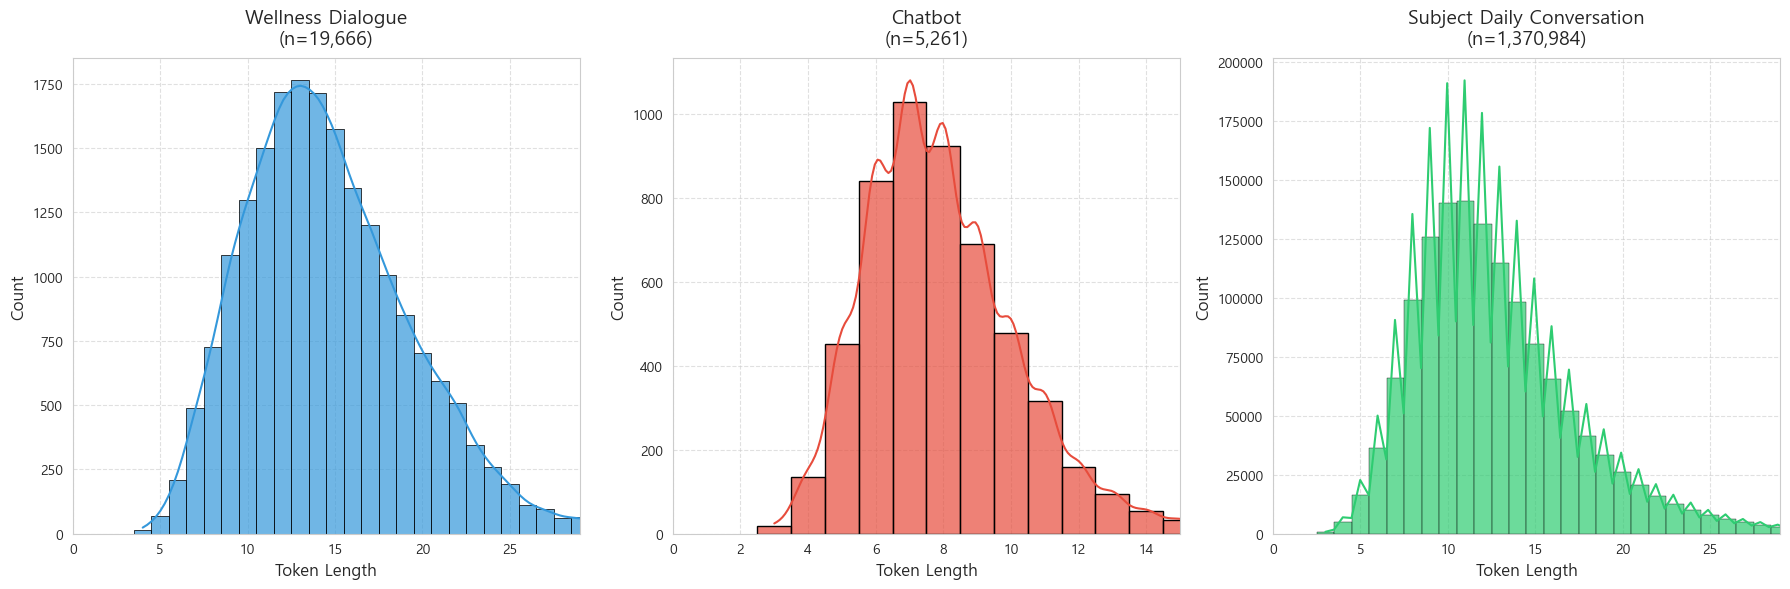

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 2. 시각화 실행
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

data_list = [wellness_lens, chatbot_lens, subject_lens]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Daily Conversation']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, lens in enumerate(data_list):
    # [수정] discrete=True와 shrink=1로 모든 막대를 빈틈없이 붙임
    sns.histplot(lens, ax=axes[i], kde=True, discrete=True, 
                 color=colors[i], edgecolor='black', alpha=0.7, shrink=1)
    
    # 제목 및 레이블
    axes[i].set_title(f"{titles[i]}\n(n={len(lens):,})", fontsize=14, pad=10)
    axes[i].set_xlabel('Token Length', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # [핵심 수정] x축이 너무 길어지지 않게 상위 1%는 잘라내고 99% 지점까지만 표시
    # 데이터가 99% 모여있는 곳까지만 x축을 잡아서 그래프를 꽉 차게 만듭니다.
    x_limit = np.percentile(lens, 99) 
    axes[i].set_xlim(0, x_limit) 
    
    # 격자선 설정
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

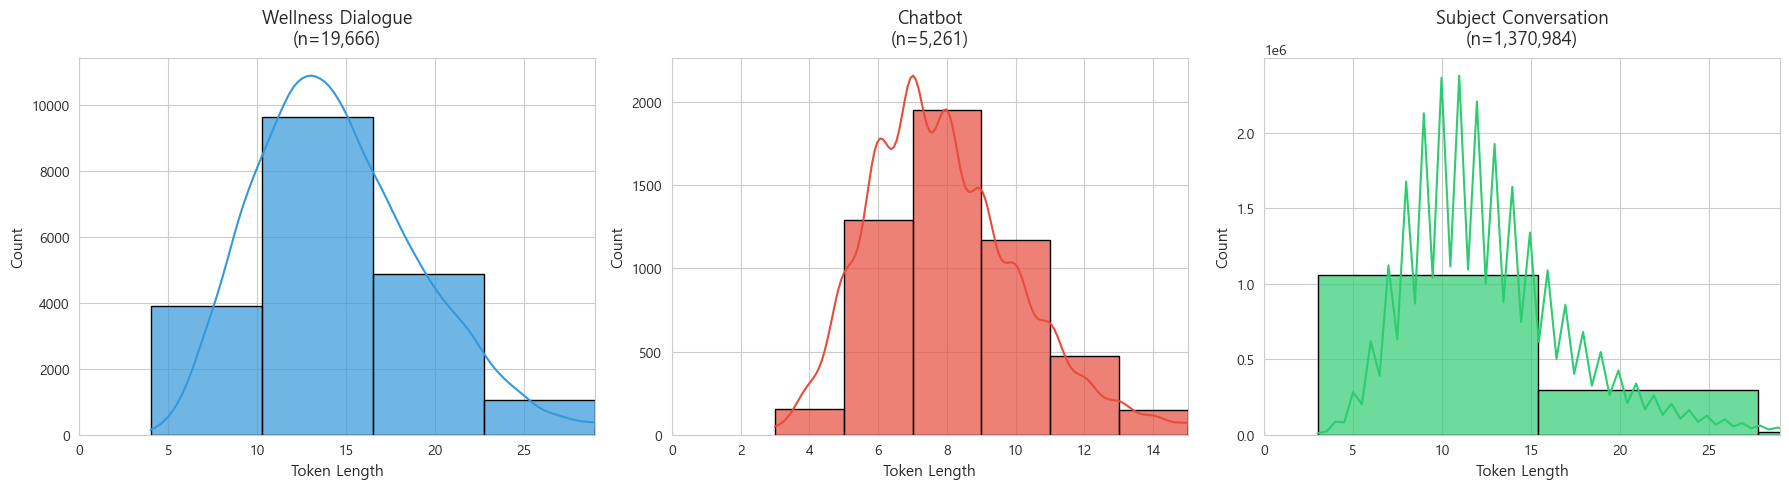

[Wellness Dialogue] 평균: 14.7, 최대: 54, 95%지점: 23.0
[Chatbot] 평균: 8.0, 최대: 19, 95%지점: 12.0
[Subject Conversation] 평균: 12.8, 최대: 102, 95%지점: 22.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import AutoTokenizer

# 1. 토크나이저 및 데이터 로드
tokenizer = AutoTokenizer.from_pretrained("monologg/koelectra-base-v3-discriminator")

# 전처리된 파일 로드 (파일명 확인 필요)
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

# 2. 토큰 길이 계산 함수
def get_token_lengths(texts, tokenizer):
    # NaN 값이 있을 경우를 대비해 str() 처리
    return [len(tokenizer.encode(str(text), add_special_tokens=True)) for text in texts]

wellness_lens = get_token_lengths(df_wellness['utterance'], tokenizer)
chatbot_lens = get_token_lengths(df_chatbot['utterance'], tokenizer)
subject_lens = get_token_lengths(df_subject['utterance'], tokenizer)

# 3. 시각화 설정
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic') # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

data_list = [wellness_lens, chatbot_lens, subject_lens]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Conversation']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, lens in enumerate(data_list):
    # [수정] bins=8로 설정하여 막대를 8개로 뭉칩니다.
    # shrink=1을 통해 막대 사이의 간격을 없애고 붙입니다.
    sns.histplot(lens, bins=8, ax=axes[i], kde=True, 
                 color=colors[i], edgecolor='black', alpha=0.7)
    
    # 제목에 데이터 정보 자동 표시
    axes[i].set_title(f"{titles[i]}\n(n={len(lens):,})", fontsize=13, pad=10)
    axes[i].set_xlabel('Token Length', fontsize=11)
    axes[i].set_ylabel('Count', fontsize=11)
    
    # x축 범위를 데이터의 상위 99% 지점까지로 잡아 아웃라이어 제거 (깔끔한 가독성)
    x_limit = np.percentile(lens, 99)
    axes[i].set_xlim(0, x_limit)

plt.tight_layout()
plt.show()

# 4. 참고용 통계치 출력
for name, lens in zip(titles, data_list):
    print(f"[{name}] 평균: {np.mean(lens):.1f}, 최대: {np.max(lens)}, 95%지점: {np.percentile(lens, 95)}")

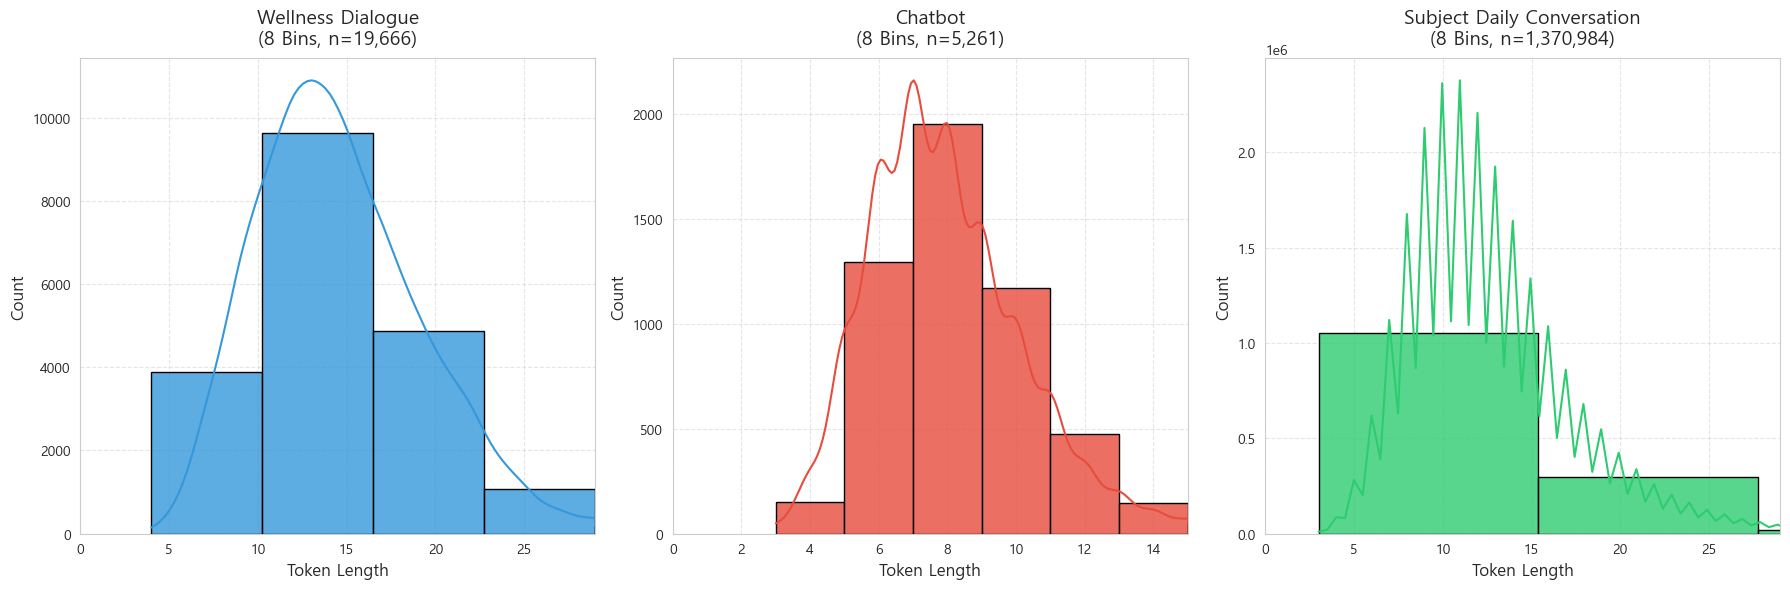

Wellness Dialogue -> 최대 토큰 길이: 54, 막대 당 범위: 3.6
Chatbot -> 최대 토큰 길이: 19, 막대 당 범위: 1.9
Subject Daily Conversation -> 최대 토큰 길이: 102, 막대 당 범위: 3.6


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 생성 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

data_list = [wellness_lens, chatbot_lens, subject_lens]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Daily Conversation']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, lens in enumerate(data_list):
    # [수정 핵심] discrete=True를 제거하고 bins=8을 설정하여 
    # 어떤 데이터든 막대를 정확히 8개로 쪼개서 그립니다.
    sns.histplot(lens, bins=8, ax=axes[i], kde=True, 
                 color=colors[i], edgecolor='black', linewidth=1, alpha=0.8)
    
    # 제목 및 레이블
    axes[i].set_title(f"{titles[i]}\n(8 Bins, n={len(lens):,})", fontsize=14, pad=10)
    axes[i].set_xlabel('Token Length', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # x축이 너무 늘어지지 않게 상위 1% 제외 (데이터 맞춤형 범위)
    x_limit = np.percentile(lens, 99) 
    axes[i].set_xlim(0, x_limit) 
    
    # 격자선 투명도 조절
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 실제 수치 확인용 출력
for title, lens in zip(titles, data_list):
    print(f"{title} -> 최대 토큰 길이: {max(lens)}, 막대 당 범위: {np.percentile(lens, 99)/8:.1f}")